<a href="https://colab.research.google.com/github/7vidushi/PatentScreener/blob/main/PatentScreener_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install openpyxl --quiet

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = '#0a0a0f'
plt.rcParams['axes.facecolor']   = '#13131e'
plt.rcParams['axes.edgecolor']   = '#2a2a3e'
plt.rcParams['text.color']       = '#f0f0f5'
plt.rcParams['axes.labelcolor']  = '#f0f0f5'
plt.rcParams['xtick.color']      = '#7a7a9a'
plt.rcParams['ytick.color']      = '#7a7a9a'
plt.rcParams['grid.color']       = '#1a1a2e'
plt.rcParams['grid.alpha']       = 0.5
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['font.size']        = 11

print("Libraries loaded")
print("Chart styling set")
print("Ready to load data")

Libraries loaded
Chart styling set
Ready to load data


In [4]:
# Cell 2 — Load your Excel data

# Load the flagged dataset (500 coded patents)
df_flagged = pd.read_excel('Global_Patent_Dataset_Flagged.xlsx',
                            sheet_name='Patents')

# Load the master combined dataset (2834 patents)
df_master = pd.read_excel('Patent_Master_Combined.xlsx',
                           sheet_name='Master Combined')

# Load country breakup sheet
df_countries = pd.read_excel('Patent_Master_Combined.xlsx',
                              sheet_name='Country Breakup')

# Quick check — print how many rows loaded
print("Flagged dataset rows:", len(df_flagged))
print("Master dataset rows:", len(df_master))
print("Countries rows:", len(df_countries))
print()

# Show column names of flagged dataset
print("Flagged dataset columns:")
print(list(df_flagged.columns))

Flagged dataset rows: 500
Master dataset rows: 2834
Countries rows: 24

Flagged dataset columns:
['#', 'Title', 'Applicants', 'Pub No.', 'Priority Date', 'Pub Date', 'Priority Year', 'Country', 'Assignee Type', 'Primary IPC', 'AI Technique', 'Category', 'Cancer Type', 'India?', '3(k)', '3(i)', '3(c)', 'Full IPC', 'Family No.', 'Relevance Flag']


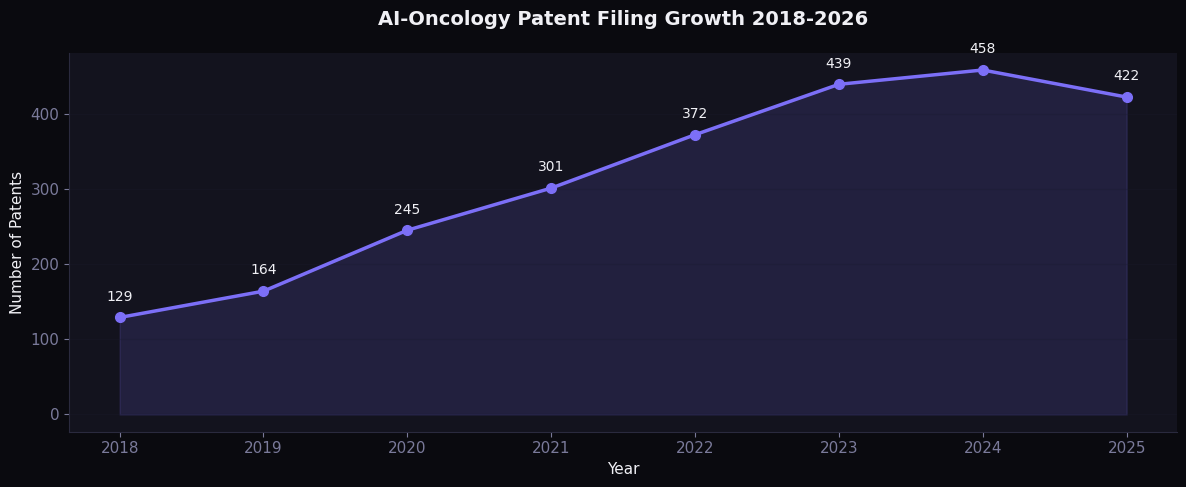

Figure1 saved


In [5]:
# Cell 3 — Chart 1: Patent Filing Growth 2018-2026

# Load year data from summary sheet
df_summary = pd.read_excel('Patent_Master_Combined.xlsx', sheet_name='Summary')

# Manually enter year data from your research
years  = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
counts = [129,  164,  245,  301,  372,  439,  458,  422]

fig, ax = plt.subplots(figsize=(12, 5))

# Plot the line
ax.plot(years, counts,
        color='#7c6ff7',
        linewidth=2.5,
        marker='o',
        markersize=7,
        markerfacecolor='#7c6ff7')

# Fill under the line
ax.fill_between(years, counts,
                alpha=0.15,
                color='#7c6ff7')

# Add value labels on each point
for x, y in zip(years, counts):
    ax.annotate(str(y),
                (x, y),
                textcoords="offset points",
                xytext=(0, 12),
                ha='center',
                fontsize=10,
                color='#f0f0f5')

ax.set_title('AI-Oncology Patent Filing Growth 2018-2026',
             fontsize=14, fontweight='bold',
             color='#f0f0f5', pad=20)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Patents')
ax.set_xticks(years)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Figure1_Filing_Growth.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure1 saved")

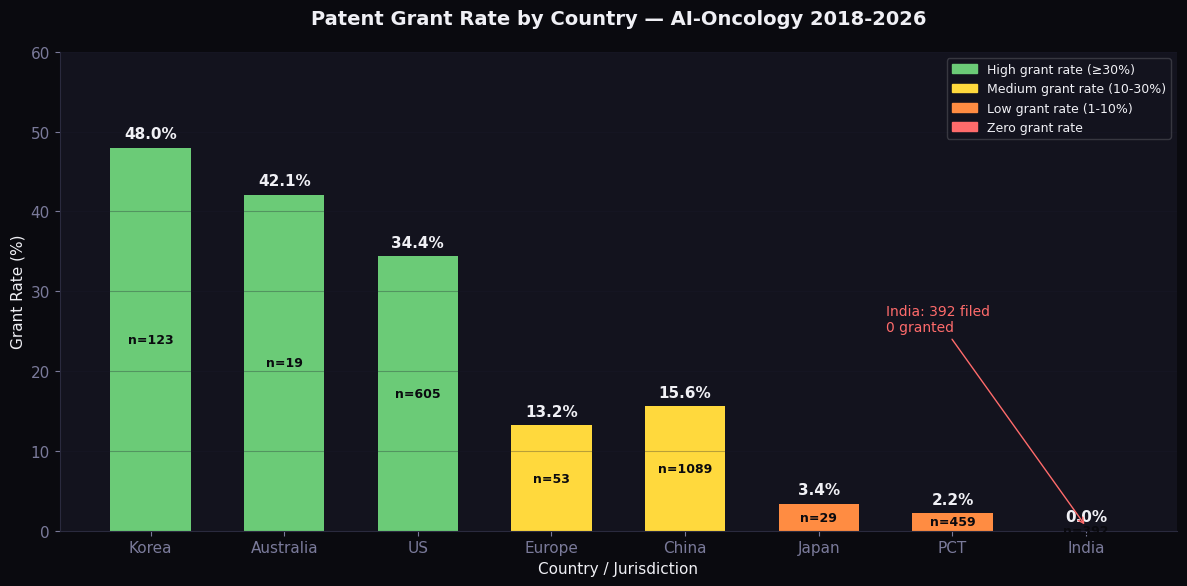

Figure2 saved


In [6]:
# Cell 4 — Chart 2: Grant Rate by Country

countries  = ['Korea', 'Australia', 'US', 'Europe', 'China', 'Japan', 'PCT', 'India']
grant_rates = [48.0, 42.1, 34.4, 13.2, 15.6, 3.4, 2.2, 0.0]
totals      = [123, 19, 605, 53, 1089, 29, 459, 392]

# Colour code — green good, yellow mid, red bad
colors = []
for rate in grant_rates:
    if rate >= 30:
        colors.append('#6bcb77')
    elif rate >= 10:
        colors.append('#ffd93d')
    elif rate > 0:
        colors.append('#ff8c42')
    else:
        colors.append('#ff6b6b')

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(countries, grant_rates,
              color=colors,
              width=0.6,
              edgecolor='none')

# Add value labels on bars
for bar, rate, total in zip(bars, grant_rates, totals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{rate}%',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold',
            color='#f0f0f5')
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height()/2,
            f'n={total}',
            ha='center', va='center',
            fontsize=9, color='#0a0a0f',
            fontweight='bold')

# Highlight India bar with annotation
ax.annotate('India: 392 filed\n0 granted',
            xy=(7, 0.5),
            xytext=(5.5, 25),
            fontsize=10,
            color='#ff6b6b',
            arrowprops=dict(arrowstyle='->', color='#ff6b6b'))

ax.set_title('Patent Grant Rate by Country — AI-Oncology 2018-2026',
             fontsize=14, fontweight='bold',
             color='#f0f0f5', pad=20)
ax.set_xlabel('Country / Jurisdiction')
ax.set_ylabel('Grant Rate (%)')
ax.set_ylim(0, 60)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_elements = [
    mpatches.Patch(color='#6bcb77', label='High grant rate (≥30%)'),
    mpatches.Patch(color='#ffd93d', label='Medium grant rate (10-30%)'),
    mpatches.Patch(color='#ff8c42', label='Low grant rate (1-10%)'),
    mpatches.Patch(color='#ff6b6b', label='Zero grant rate')
]
ax.legend(handles=legend_elements, loc='upper right',
          framealpha=0.2, fontsize=9)

plt.tight_layout()
plt.savefig('Figure2_Grant_Rates.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure2 saved")

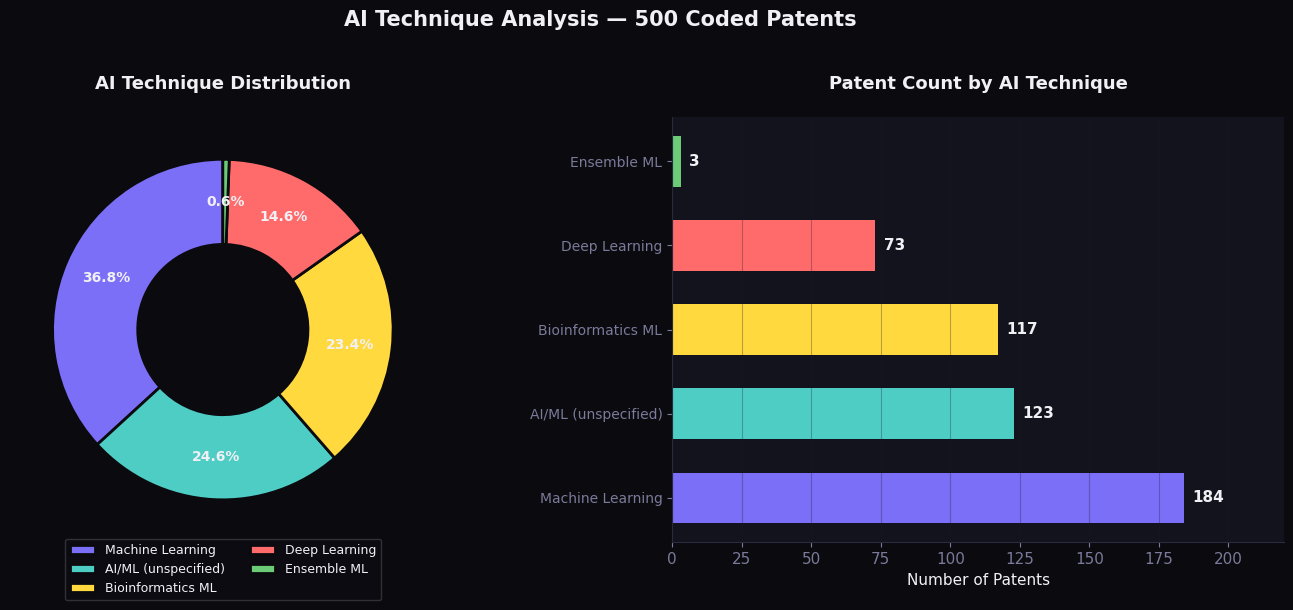

Figure3 saved


In [7]:
# Cell 5 — Chart 3: AI Technique Distribution

ai_techniques = ['Machine Learning', 'AI/ML (unspecified)',
                 'Bioinformatics ML', 'Deep Learning', 'Ensemble ML']
ai_counts = [184, 123, 117, 73, 3]
ai_colors = ['#7c6ff7', '#4ecdc4', '#ffd93d', '#ff6b6b', '#6bcb77']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left — Donut chart
wedges, texts, autotexts = ax1.pie(
    ai_counts,
    labels=None,
    colors=ai_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='#0a0a0f', linewidth=2)
)

for autotext in autotexts:
    autotext.set_color('#f0f0f5')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax1.legend(wedges, ai_techniques,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.15),
           ncol=2, fontsize=9,
           framealpha=0.2)

ax1.set_title('AI Technique Distribution',
              fontsize=13, fontweight='bold',
              color='#f0f0f5', pad=20)

# Right — Horizontal bar chart
y_pos = range(len(ai_techniques))
bars = ax2.barh(list(y_pos), ai_counts,
                color=ai_colors,
                edgecolor='none',
                height=0.6)

for bar, count in zip(bars, ai_counts):
    ax2.text(bar.get_width() + 3,
             bar.get_y() + bar.get_height()/2,
             str(count),
             va='center', fontsize=11,
             fontweight='bold', color='#f0f0f5')

ax2.set_yticks(list(y_pos))
ax2.set_yticklabels(ai_techniques, fontsize=10)
ax2.set_xlabel('Number of Patents')
ax2.set_title('Patent Count by AI Technique',
              fontsize=13, fontweight='bold',
              color='#f0f0f5', pad=20)
ax2.grid(axis='x', alpha=0.3)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlim(0, 220)

plt.suptitle('AI Technique Analysis — 500 Coded Patents',
             fontsize=15, fontweight='bold',
             color='#f0f0f5', y=1.02)

plt.tight_layout()
plt.savefig('Figure3_AI_Techniques.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure3 saved")

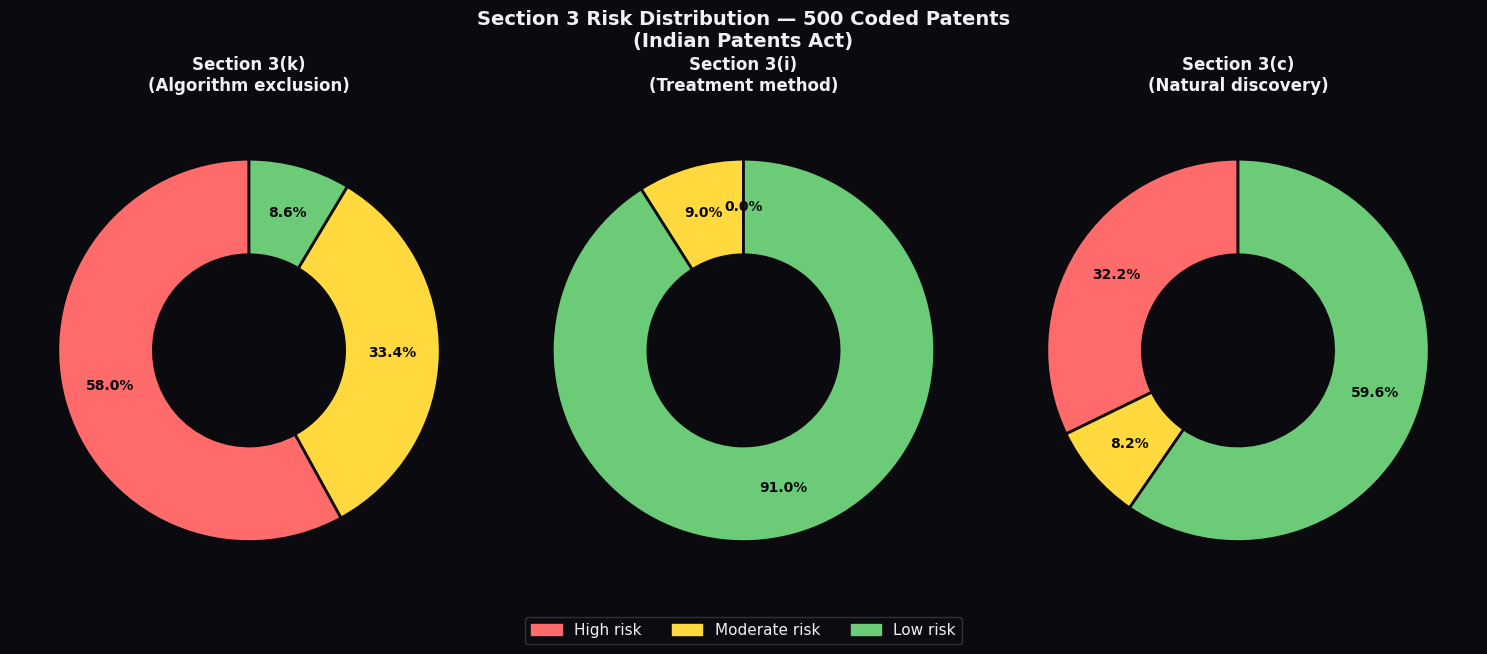

Figure4 saved


In [8]:
# Cell 6 — Chart 4: Section 3 Risk Distribution

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

risk_labels = ['High', 'Moderate', 'Low']
risk_colors = ['#ff6b6b', '#ffd93d', '#6bcb77']

# Data for each section
risk_3k = [290, 167, 43]
risk_3i = [0, 45, 455]
risk_3c = [161, 41, 298]

sections = [
    (risk_3k, 'Section 3(k)', 'Algorithm exclusion'),
    (risk_3i, 'Section 3(i)', 'Treatment method'),
    (risk_3c, 'Section 3(c)', 'Natural discovery')
]

for ax, (data, title, subtitle) in zip(axes, sections):
    wedges, texts, autotexts = ax.pie(
        data,
        labels=None,
        colors=risk_colors,
        autopct='%1.1f%%',
        startangle=90,
        pctdistance=0.75,
        wedgeprops=dict(width=0.5,
                       edgecolor='#0a0a0f',
                       linewidth=2)
    )

    for autotext in autotexts:
        autotext.set_color('#0a0a0f')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')

    ax.set_title(f'{title}\n({subtitle})',
                 fontsize=12, fontweight='bold',
                 color='#f0f0f5', pad=15)

    # Add counts in centre
    total = sum(data)
    for i, (label, count) in enumerate(zip(risk_labels, data)):
        pct = count/total*100
        if pct > 5:
            pass

# Add shared legend at bottom
legend_elements = [
    mpatches.Patch(color='#ff6b6b', label=f'High risk'),
    mpatches.Patch(color='#ffd93d', label=f'Moderate risk'),
    mpatches.Patch(color='#6bcb77', label=f'Low risk')
]
fig.legend(handles=legend_elements,
           loc='lower center',
           ncol=3,
           fontsize=11,
           framealpha=0.2,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Section 3 Risk Distribution — 500 Coded Patents\n(Indian Patents Act)',
             fontsize=14, fontweight='bold',
             color='#f0f0f5', y=1.02)

plt.tight_layout()
plt.savefig('Figure4_Section3_Risk.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure4 saved")

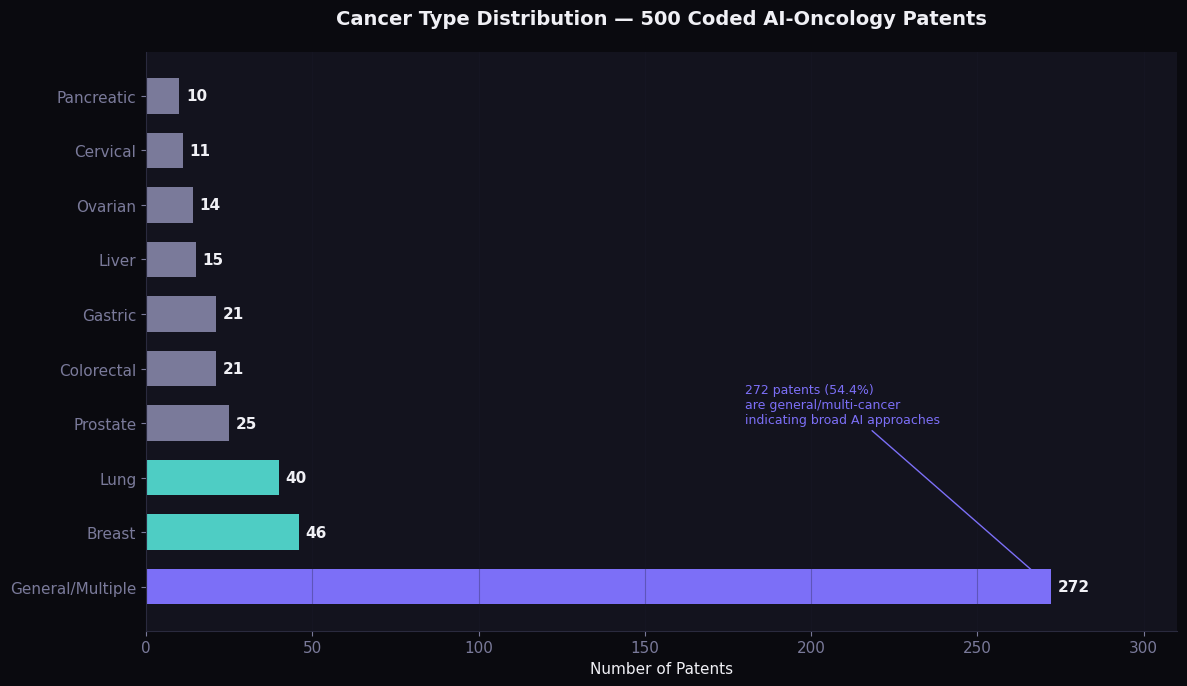

Figure5 saved


In [9]:
# Cell 7 — Chart 5: Cancer Type Distribution

cancer_types = ['General/Multiple', 'Breast', 'Lung', 'Prostate',
                'Colorectal', 'Gastric', 'Liver', 'Ovarian',
                'Cervical', 'Pancreatic']
cancer_counts = [272, 46, 40, 25, 21, 21, 15, 14, 11, 10]

# Colour — highlight top 3
colors = ['#7c6ff7', '#4ecdc4', '#4ecdc4',
          '#7a7a9a', '#7a7a9a', '#7a7a9a',
          '#7a7a9a', '#7a7a9a', '#7a7a9a', '#7a7a9a']

fig, ax = plt.subplots(figsize=(12, 7))

y_pos = range(len(cancer_types))
bars = ax.barh(list(y_pos), cancer_counts,
               color=colors,
               edgecolor='none',
               height=0.65)

# Value labels
for bar, count in zip(bars, cancer_counts):
    ax.text(bar.get_width() + 2,
            bar.get_y() + bar.get_height()/2,
            str(count),
            va='center', fontsize=11,
            fontweight='bold', color='#f0f0f5')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(cancer_types, fontsize=11)
ax.set_xlabel('Number of Patents')
ax.set_title('Cancer Type Distribution — 500 Coded AI-Oncology Patents',
             fontsize=14, fontweight='bold',
             color='#f0f0f5', pad=20)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 310)

# Annotation
ax.annotate('272 patents (54.4%)\nare general/multi-cancer\nindicating broad AI approaches',
            xy=(272, 0),
            xytext=(180, 3),
            fontsize=9,
            color='#7c6ff7',
            arrowprops=dict(arrowstyle='->',
                          color='#7c6ff7'))

plt.tight_layout()
plt.savefig('Figure5_Cancer_Types.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure5 saved")

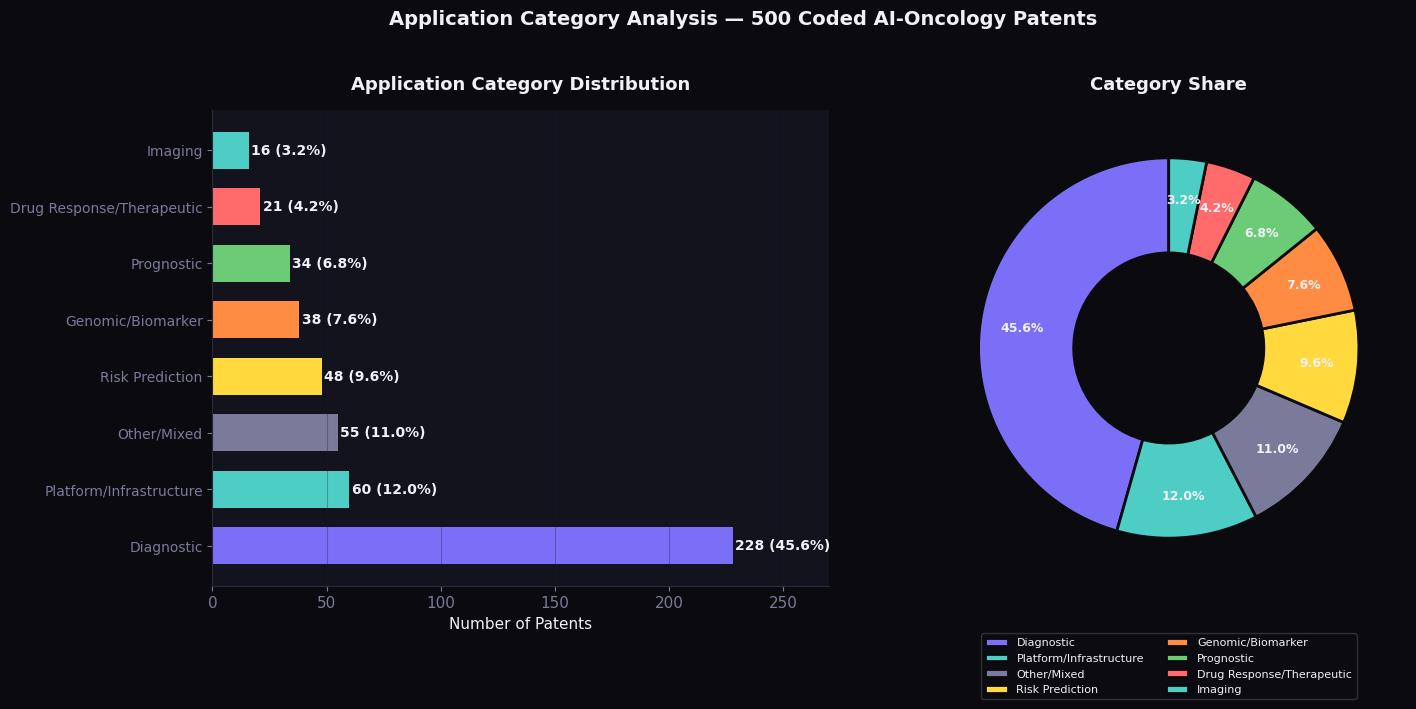

Figure6 saved


In [10]:
# Cell 8 — Chart 6: Application Category Breakdown

categories = ['Diagnostic', 'Platform/Infrastructure',
              'Other/Mixed', 'Risk Prediction',
              'Genomic/Biomarker', 'Prognostic',
              'Drug Response/Therapeutic', 'Imaging']
cat_counts = [228, 60, 55, 48, 38, 34, 21, 16]
cat_colors = ['#7c6ff7', '#4ecdc4', '#7a7a9a',
              '#ffd93d', '#ff8c42', '#6bcb77',
              '#ff6b6b', '#4ecdc4']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Left — bar chart
y_pos = range(len(categories))
bars = ax1.barh(list(y_pos), cat_counts,
                color=cat_colors,
                edgecolor='none',
                height=0.65)

for bar, count in zip(bars, cat_counts):
    pct = count / sum(cat_counts) * 100
    ax1.text(bar.get_width() + 1,
             bar.get_y() + bar.get_height()/2,
             f'{count} ({pct:.1f}%)',
             va='center', fontsize=10,
             fontweight='bold', color='#f0f0f5')

ax1.set_yticks(list(y_pos))
ax1.set_yticklabels(categories, fontsize=10)
ax1.set_xlabel('Number of Patents')
ax1.set_title('Application Category Distribution',
              fontsize=13, fontweight='bold',
              color='#f0f0f5', pad=15)
ax1.grid(axis='x', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_xlim(0, 270)

# Right — donut chart
wedges, texts, autotexts = ax2.pie(
    cat_counts,
    labels=None,
    colors=cat_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.5,
                   edgecolor='#0a0a0f',
                   linewidth=2)
)

for autotext in autotexts:
    autotext.set_color('#f0f0f5')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

ax2.legend(wedges, categories,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.25),
           ncol=2, fontsize=8,
           framealpha=0.2)

ax2.set_title('Category Share',
              fontsize=13, fontweight='bold',
              color='#f0f0f5', pad=15)

plt.suptitle('Application Category Analysis — 500 Coded AI-Oncology Patents',
             fontsize=14, fontweight='bold',
             color='#f0f0f5', y=1.02)

plt.tight_layout()
plt.savefig('Figure6_Categories.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure6 saved")

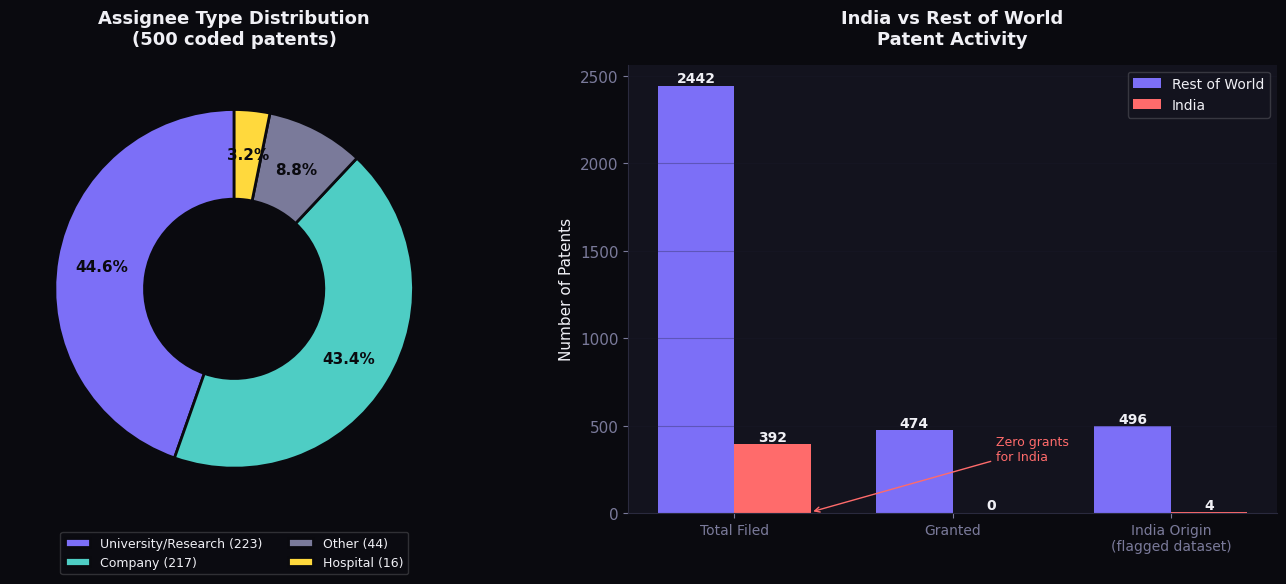

Figure7 saved


In [11]:
# Cell 9 — Chart 7: Assignee Type and India Analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left — Assignee type breakdown
assignee_types  = ['University/Research', 'Company', 'Other', 'Hospital']
assignee_counts = [223, 217, 44, 16]
assignee_colors = ['#7c6ff7', '#4ecdc4', '#7a7a9a', '#ffd93d']

wedges, texts, autotexts = axes[0].pie(
    assignee_counts,
    labels=None,
    colors=assignee_colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.5,
                   edgecolor='#0a0a0f',
                   linewidth=2)
)

for autotext in autotexts:
    autotext.set_color('#0a0a0f')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

axes[0].legend(wedges,
               [f'{t} ({c})' for t, c in
                zip(assignee_types, assignee_counts)],
               loc='lower center',
               bbox_to_anchor=(0.5, -0.15),
               ncol=2, fontsize=9,
               framealpha=0.2)

axes[0].set_title('Assignee Type Distribution\n(500 coded patents)',
                  fontsize=13, fontweight='bold',
                  color='#f0f0f5', pad=15)

# Right — India vs World comparison
categories_india = ['Total Filed', 'Granted', 'India Origin\n(flagged dataset)']
india_vals = [392, 0, 4]
world_vals = [2442, 474, 496]

x = np.arange(len(categories_india))
width = 0.35

bars1 = axes[1].bar(x - width/2, world_vals,
                    width, label='Rest of World',
                    color='#7c6ff7',
                    edgecolor='none')
bars2 = axes[1].bar(x + width/2, india_vals,
                    width, label='India',
                    color='#ff6b6b',
                    edgecolor='none')

# Value labels
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 str(int(bar.get_height())),
                 ha='center', fontsize=10,
                 fontweight='bold', color='#f0f0f5')

for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20,
                 str(int(bar.get_height())),
                 ha='center', fontsize=10,
                 fontweight='bold', color='#f0f0f5')

axes[1].set_title('India vs Rest of World\nPatent Activity',
                  fontsize=13, fontweight='bold',
                  color='#f0f0f5', pad=15)
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories_india, fontsize=10)
axes[1].set_ylabel('Number of Patents')
axes[1].legend(framealpha=0.2, fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Highlight the 0 grants for India
axes[1].annotate('Zero grants\nfor India',
                 xy=(0.35, 5),
                 xytext=(1.2, 300),
                 fontsize=9,
                 color='#ff6b6b',
                 arrowprops=dict(arrowstyle='->',
                               color='#ff6b6b'))

plt.tight_layout()
plt.savefig('Figure7_Assignee_India.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure7 saved")

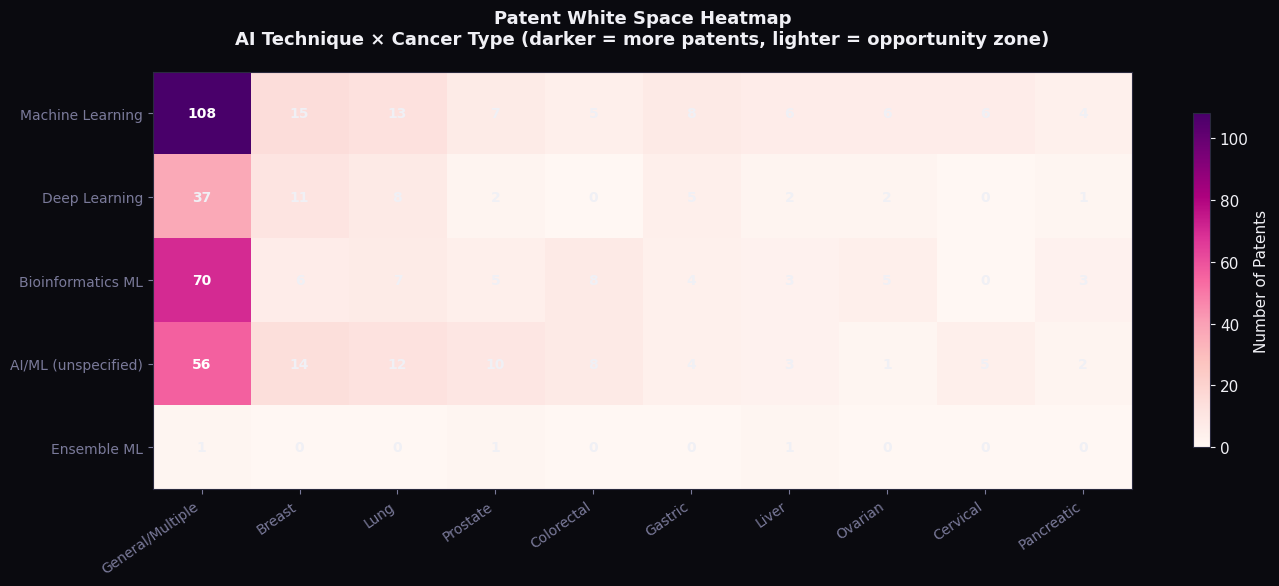

Figure8 saved

White space analysis:
Total combinations possible: 50
Empty zones (0 patents): 10
Low density zones (1-2 patents): 9
Total white space opportunities: 19


In [12]:
# Cell 10 — Chart 8: White Space Heatmap

# Count patents per AI technique x Cancer type combination
ai_techs = ['Machine Learning', 'Deep Learning',
            'Bioinformatics ML', 'AI/ML (unspecified)', 'Ensemble ML']
cancer_types = ['General/Multiple', 'Breast', 'Lung',
                'Prostate', 'Colorectal', 'Gastric',
                'Liver', 'Ovarian', 'Cervical', 'Pancreatic']

# Count from your flagged dataset
matrix = np.zeros((len(ai_techs), len(cancer_types)))

for i, ai in enumerate(ai_techs):
    for j, cancer in enumerate(cancer_types):
        count = len(df_flagged[
            (df_flagged['AI Technique'] == ai) &
            (df_flagged['Cancer Type'] == cancer)
        ])
        matrix[i][j] = count

fig, ax = plt.subplots(figsize=(14, 6))

# Custom colormap — dark = empty (white space), bright = crowded
im = ax.imshow(matrix,
               cmap='RdPu',
               aspect='auto',
               vmin=0,
               vmax=matrix.max())

# Add colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Number of Patents', color='#f0f0f5', fontsize=11)
cbar.ax.yaxis.set_tick_params(color='#f0f0f5')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#f0f0f5')

# Add count numbers in each cell
for i in range(len(ai_techs)):
    for j in range(len(cancer_types)):
        count = int(matrix[i][j])
        color = 'white' if count > matrix.max()/2 else '#f0f0f5'
        ax.text(j, i, str(count),
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color=color)

ax.set_xticks(range(len(cancer_types)))
ax.set_xticklabels(cancer_types,
                   rotation=35,
                   ha='right',
                   fontsize=10)
ax.set_yticks(range(len(ai_techs)))
ax.set_yticklabels(ai_techs, fontsize=10)

ax.set_title('Patent White Space Heatmap\nAI Technique × Cancer Type (darker = more patents, lighter = opportunity zone)',
             fontsize=13, fontweight='bold',
             color='#f0f0f5', pad=20)

plt.tight_layout()
plt.savefig('Figure8_Whitespace_Heatmap.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure8 saved")
print()
print("White space analysis:")
print(f"Total combinations possible: {len(ai_techs) * len(cancer_types)}")
empty = np.sum(matrix == 0)
low   = np.sum((matrix > 0) & (matrix <= 2))
print(f"Empty zones (0 patents): {empty}")
print(f"Low density zones (1-2 patents): {low}")
print(f"Total white space opportunities: {empty + low}")

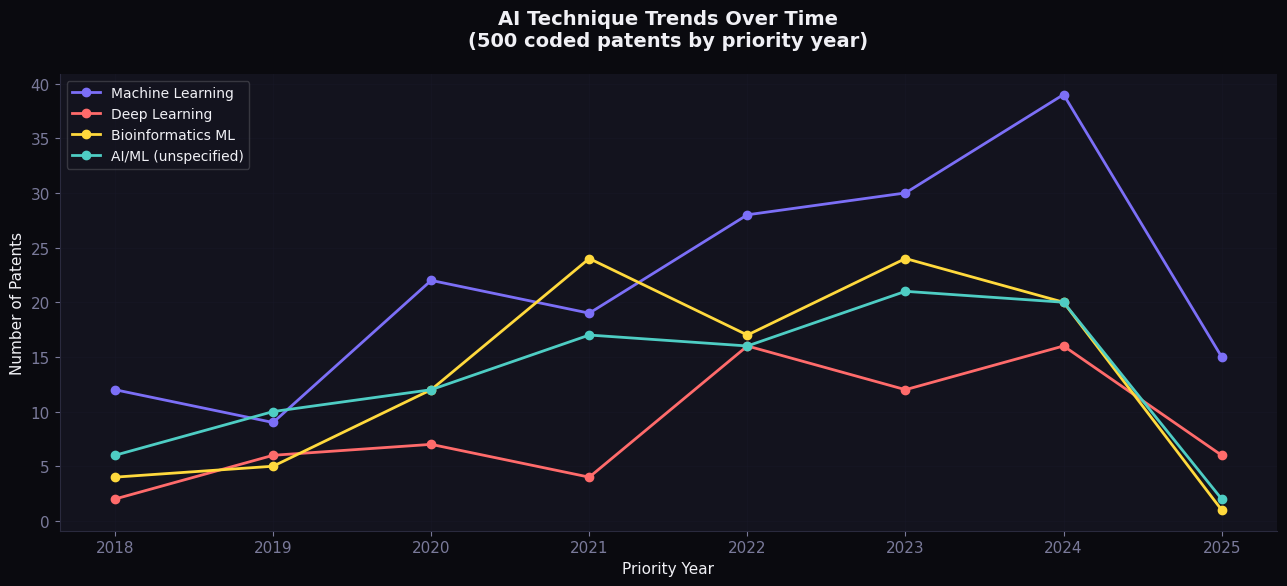

Figure9 saved


In [13]:
# Cell 11 — Chart 9: Year-wise trend by AI Technique

# Count from flagged dataset by year and AI technique
years = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

ai_techs_trend = ['Machine Learning', 'Deep Learning',
                  'Bioinformatics ML', 'AI/ML (unspecified)']
colors_trend   = ['#7c6ff7', '#ff6b6b', '#ffd93d', '#4ecdc4']

fig, ax = plt.subplots(figsize=(13, 6))

for ai, color in zip(ai_techs_trend, colors_trend):
    yearly_counts = []
    for year in years:
        count = len(df_flagged[
            (df_flagged['AI Technique'] == ai) &
            (df_flagged['Priority Year'] == year)
        ])
        yearly_counts.append(count)

    ax.plot(years, yearly_counts,
            color=color,
            linewidth=2,
            marker='o',
            markersize=6,
            label=ai)

ax.set_title('AI Technique Trends Over Time\n(500 coded patents by priority year)',
             fontsize=14, fontweight='bold',
             color='#f0f0f5', pad=20)
ax.set_xlabel('Priority Year')
ax.set_ylabel('Number of Patents')
ax.set_xticks(years)
ax.legend(framealpha=0.2, fontsize=10)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('Figure9_Technique_Trends.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='#0a0a0f')
plt.show()
print("Figure9 saved")

In [15]:
# Cell 12 — Download all figures and print summary

from google.colab import files
import os

print("=" * 50)
print("PATENTSCREENER ANALYSIS — COMPLETE")
print("=" * 50)
print()
print("DATASET SUMMARY")
print(f"Total patents analysed:     2,834")
print(f"Coded patents (Section 3):    500")
print(f"Countries covered:             24")
print(f"Years covered:          2018-2026")
print()
print("KEY FINDINGS")
print(f"India grant rate:             0.0%")
print(f"Korea grant rate:            48.0%")
print(f"US grant rate:               34.4%")
print(f"High S.3(k) risk patents:     290 (58%)")
print(f"High S.3(c) risk patents:     161 (32%)")
print(f"White space opportunities:     19")
print()
print("FIGURES GENERATED")

figures = [
    'Figure1_Filing_Growth.png',
    'Figure2_Grant_Rates.png',
    'Figure3_AI_Techniques.png',
    'Figure4_Section3_Risk.png',
    'Figure5_Cancer_Types.png',
    'Figure6_Categories.png',
    'Figure7_Assignee_India.png',
    'Figure8_Whitespace_Heatmap.png',
    'Figure9_Technique_Trends.png'
]

for i, fig in enumerate(figures, 1):
    if os.path.exists(fig):
        size = os.path.getsize(fig) / 1024
        print(f"  Figure {i}: {fig} ({size:.0f} KB) ✓")
    else:
        print(f"  Figure {i}: {fig} — NOT FOUND")

print()
print("Downloading all figures...")
print()

for fig in figures:
    if os.path.exists(fig):
        files.download(fig)
        print(f"Downloaded: {fig}")

print()
print("All done. Check your Downloads folder.")

PATENTSCREENER ANALYSIS — COMPLETE

DATASET SUMMARY
Total patents analysed:     2,834
Coded patents (Section 3):    500
Countries covered:             24
Years covered:          2018-2026

KEY FINDINGS
India grant rate:             0.0%
Korea grant rate:            48.0%
US grant rate:               34.4%
High S.3(k) risk patents:     290 (58%)
High S.3(c) risk patents:     161 (32%)
White space opportunities:     19

FIGURES GENERATED
  Figure 1: Figure1_Filing_Growth.png (146 KB) ✓
  Figure 2: Figure2_Grant_Rates.png (231 KB) ✓
  Figure 3: Figure3_AI_Techniques.png (247 KB) ✓
  Figure 4: Figure4_Section3_Risk.png (310 KB) ✓
  Figure 5: Figure5_Cancer_Types.png (189 KB) ✓
  Figure 6: Figure6_Categories.png (379 KB) ✓
  Figure 7: Figure7_Assignee_India.png (260 KB) ✓
  Figure 8: Figure8_Whitespace_Heatmap.png (257 KB) ✓
  Figure 9: Figure9_Technique_Trends.png (354 KB) ✓




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: Figure1_Filing_Growth.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: Figure8_Whitespace_Heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: Figure9_Technique_Trends.png

All done. Check your Downloads folder.
